### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(42)
tf.set_random_seed(42)
tf.__version__
tf.keras.__version__
tf.reset_default_graph()

#### Collect Fashion mnist data from tf.keras.datasets 

In [0]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [20]:
train_images.shape

(60000, 28, 28)

In [21]:
train_labels.shape

(60000,)

In [22]:
test_images.shape

(10000, 28, 28)

In [23]:
test_labels.shape

(10000,)

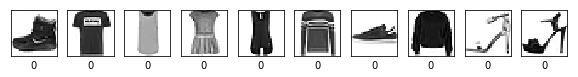

In [24]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(np.argmax(train_labels[i]))
plt.show()

#### Change train and test labels into one-hot vectors

In [0]:
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels)
test_labels_one_hot  = tf.keras.utils.to_categorical(test_labels)

In [26]:
train_labels_one_hot[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [27]:
test_labels_one_hot[0:2]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [0]:
tf.keras.backend.clear_session()
# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()
# Reshape the data from 2D (28,28) to 3D(28,28, 1)
model.add(tf.keras.layers.Reshape(target_shape=(28,28,1), input_shape=(28,28)))
# Normalize the data
model.add(tf.keras.layers.BatchNormalization())

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [29]:
# Flatten the output
model.add(tf.keras.layers.Flatten())

# Add first Dense layer
model.add(tf.keras.layers.Dense(200, activation='relu'))

# Add first Dense layer
model.add(tf.keras.layers.Dense(100, activation='relu'))

# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.25))

W0824 14:52:15.693987 140146247526272 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
# Add output layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1

In [35]:
model.fit(train_images, train_labels_one_hot, validation_data=(test_images, test_labels_one_hot), shuffle=True, epochs=10)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 12s 201us/sample - loss: 0.4907 - acc: 0.8238 - val_loss: 0.3914 - val_acc: 0.8605
Epoch 2/10
60000/60000 [==============================] - 9s 153us/sample - loss: 0.3724 - acc: 0.8637 - val_loss: 0.3768 - val_acc: 0.8568
Epoch 3/10
60000/60000 [==============================] - 9s 153us/sample - loss: 0.3350 - acc: 0.8760 - val_loss: 0.3536 - val_acc: 0.8733
Epoch 4/10
60000/60000 [==============================] - 9s 152us/sample - loss: 0.3141 - acc: 0.8838 - val_loss: 0.3977 - val_acc: 0.8585
Epoch 5/10
60000/60000 [==============================] - 9s 154us/sample - loss: 0.2939 - acc: 0.8920 - val_loss: 0.3467 - val_acc: 0.8756
Epoch 6/10
60000/60000 [==============================] - 9s 153us/sample - loss: 0.2807 - acc: 0.8958 - val_loss: 0.3462 - val_acc: 0.8763
Epoch 7/10
60000/60000 [==============================] - 9s 153us/sample - loss: 0.2692 - acc: 0.8992 - val_

In [36]:
model.evaluate(test_images, test_labels_one_hot)

10000/10000 [==============================] - 1s 82us/sample - loss: 0.3277 - acc: 0.8850


[0.32766951636075975, 0.885]